<a href="https://colab.research.google.com/github/RobClark1254/Robert_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [49]:
#Please write the code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
#i am not sure if i am doing this wrong, but even with the csv in the folder it doesn't open this is the only thing that works for me.
from google.colab import files
files.upload()

CSV_PATH = 'car_purchase_data.csv'

data = pd.read_csv(CSV_PATH)
display(data.head())
print('Shape:', data.shape)

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [50]:
#Please write the code here
X = data[['Age', 'Salary']]
y = data['Purchased']

print('X shape;', X.shape)
print('y distribution:\n', y.value_counts())

X shape; (400, 2)
y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [64]:
#Please write the code here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)

print("Train size: ", X_train.shape[0], " Test size: ", X_test.shape[0])

Train size:  320  Test size:  80


### Step 4: Feature Scaling

In [65]:
#Please write the code here
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#polynomial scale features talked more about in reflection section
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test  = poly.transform(X_test)
print('Scaling complete')

Scaling complete


### Step 5: Train Logistic Regression Model

In [66]:
#Please write the code here
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


### Step 6: Predict and Evaluate

In [67]:
#Please write the code here
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('Accuracy: ', acc)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n", classification_report(y_test, y_pred))

Accuracy:  0.9125

Confusion Matrix: 
 [[47  4]
 [ 3 26]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        51
           1       0.87      0.90      0.88        29

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



### Step 7: Visualization of Decision Regions

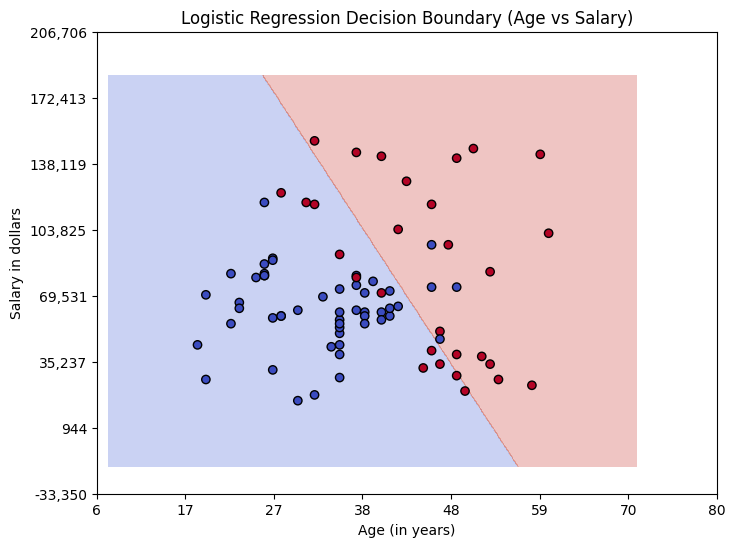

In [68]:
#Please write the code here
X_set, y_set = X_test[:, :2], y_test.values
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train[:, :2], y_train)

x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
X1, X2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=0.01)
)

Z = model_2d.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

plt.figure(figsize=(8,6))
plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary (Age vs Salary)')
plt.xlabel('Age (in years)')
plt.ylabel('Salary in dollars')
#added this section to get rid of the standardized ticks on the scale because they weren't readable in the visualization.
#makes the values on the x and y axis a little messy, but at least it is readable
x_nums = plt.gca().get_xticks()
y_nums = plt.gca().get_yticks()
x_labels = [f"{scaler.mean_[0] + t * scaler.scale_[0]:.0f}" for t in x_nums]
y_labels = [f"{scaler.mean_[1] + t * scaler.scale_[1]:,.0f}" for t in y_nums]
plt.xticks(x_nums, x_labels)
plt.yticks(y_nums, y_labels)
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. It can be used for classification because it uses a cutoff point to put probabilities into a binary class. If above .5 they are likely to buy and below .5 they are not.

2. I would say the model and the visualization show that older groups and people with a lot of money are more inclined to buy vehicles.

3. I think the first problem is that the dataset is very small. I think it is unlikely such a small dataset of only 400 examples could be considered an accurate model especially when limited to only factors of age and salary. I think the biggest factor for low accuracy is the models inability to properly classify the concetration of buyers at the higher age/salary section without polynomal features.

4. I already added additional features. I added Polynomial Scaling because the only test_size that was above the 87.5 threshhold was a value of 0.02 which I know if overfitting. Using a normal test size of 0.20 only gave me results around 81% and I didn't want partial credit. By adding the polynomial scaling the results weren't limited to a straight line. As answered in question two, and shown in the visual, the amount of buyers is mainly clustered around older groups and this allows the high concentration of buyers be more accurately represented.